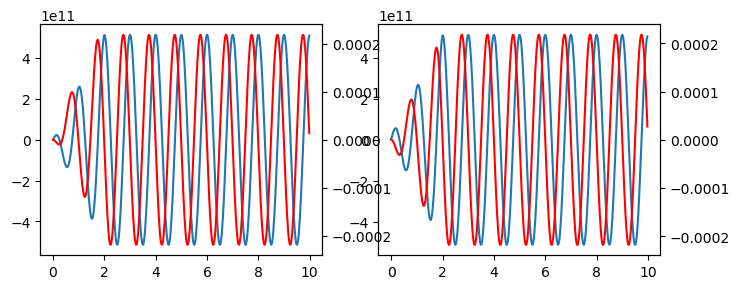

In [ ]:
import numpy as np
from grid import UniformCartesianGrid
from  Field import electricField, lambda2T, env_sin2, env_lin, potentialVectorField
from pprint import pprint
import matplotlib.pyplot as plt

def my_env(t:np.array, parameters):
    dt=t[1]-t[0]
    tmax=t[-1]+dt
    return np.sin(t/tmax*np.pi)

lambda0=800
T0=lambda2T(lambda0*1e-9)

# temporal grid
time=UniformCartesianGrid(1,[0,10*T0], 500)

# electricField
I0=3.51e16
Efield=electricField(time,I0,800, env=env_lin, env_parameters={'start':0, 'end':1, 'ton':2*T0/time.x[-1], 'toff':2*T0/time.x[-1]*0})
Afield=potentialVectorField(time,I0,800, phi_rad=-np.pi/2, env=env_lin, env_parameters={'start':0, 'end':1, 'ton':2*T0/time.x[-1], 'toff':2*T0/time.x[-1]*0})

#pprint(Efield.__dict__)

fig, ax= plt.subplots(1,2,figsize=(8,3))

ax1=ax[0].twinx()
ax[0].plot(time.x/T0, Efield.E)
ax1.plot(time.x/T0, Efield.A, c='r')

ax1=ax[1].twinx()
ax[1].plot(time.x/T0, Afield.E)
ax1.plot(time.x/T0, Afield.A, c='r')


-0.7853981633974483
-0.7853981633974483
-0.7853981633974483
0.7853981633974483
0.7853981633974483
-1.1071487177940902
-0.7853981633974483
-0.46364760900080637
0.7853981633974483
1.1071487177940902
-1.249045772398254
-0.7853981633974483
-0.3217505543966425
0.7853981633974483
1.249045772398254
-1.365037903761152
-0.7853981633974483
-0.2057584230337445
0.7853981633974483
1.365037903761152
-1.47011736639973
-0.7853981633974483
-0.1006789603951666
0.7853981633974483
1.47011736639973
-1.5707963109835084
-0.7853981633974483
-1.581138830084189e-08
0.7853981633974483
1.5707963109835084
-1.4701173663997298
-0.7853981633974483
-0.10067896039516672
0.7853981633974483
1.4701173663997298
-1.365037903761152
-0.7853981633974483
-0.20575842303374467
0.7853981633974483
1.365037903761152
-1.249045772398254
-0.7853981633974483
-0.3217505543966426
0.7853981633974483
1.249045772398254
-1.1071487177940902
-0.7853981633974483
-0.46364760900080637
0.7853981633974483
1.1071487177940902
-0.7853981633974483
-0.78

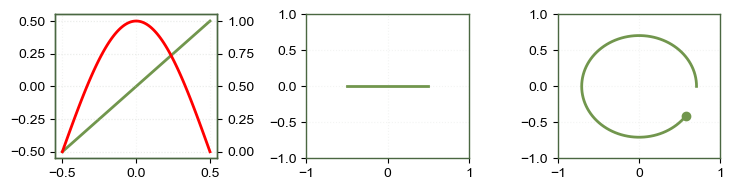

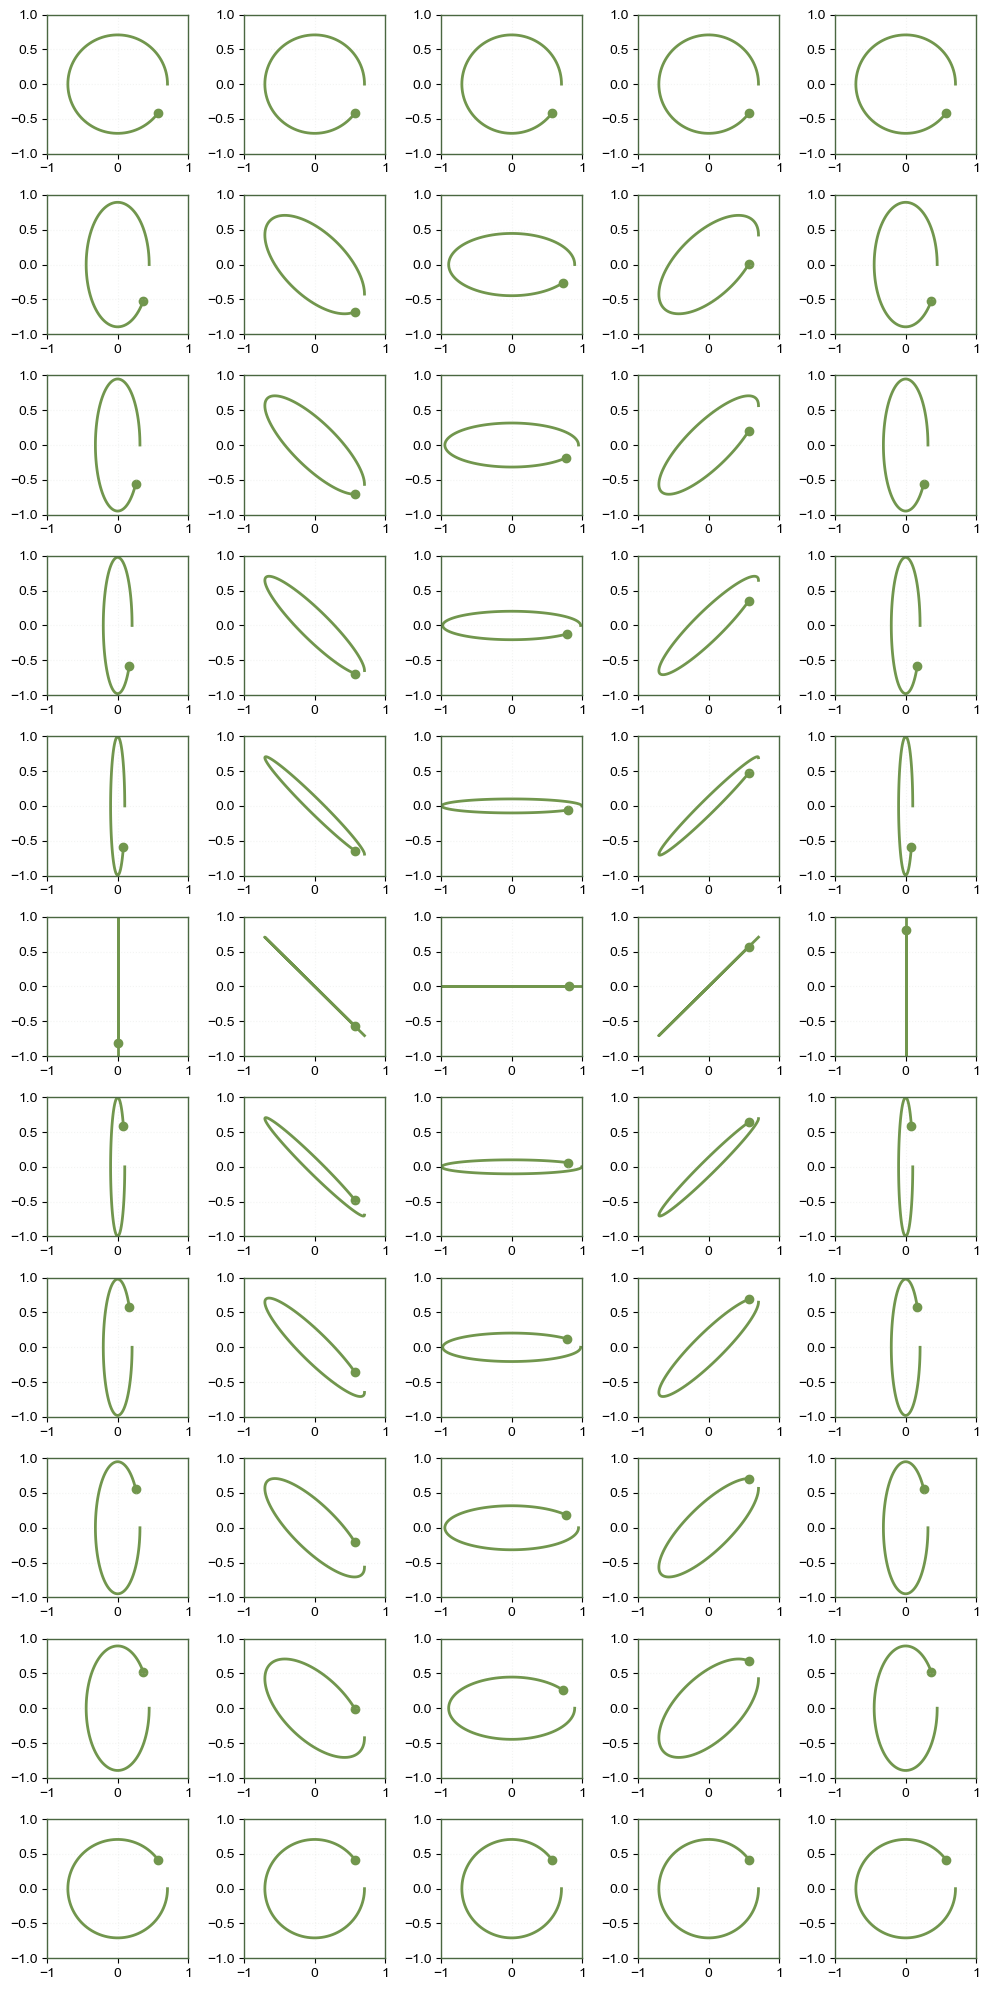

In [1]:
import numpy as np
from grid import UniformCartesianGrid
from  Field import electricField, lambda2T, env_sin2, env_lin, potentialVectorField
from pprint import pprint
import matplotlib.pyplot as plt
import obsidian_style


def Phidelta_phi(chi, ellip):

    def sign(a):
        return np.where(a>0, 1, -1)
    
    # argument_num=np.sqrt(np.tan(2*chi)**2+ellip**2+1e-15)
    # argument_denom=np.sqrt(1-ellip**2)
    # Phi=0.5*np.atan2(argument_num, argument_denom) 

    # Phi=np.where((chi >= -np.pi/2) & (chi <= -np.pi/4), Phi-np.pi/2, Phi)
    # Phi=np.where((chi > -np.pi/4) & (chi <= 0), -Phi, Phi)
    # Phi=np.where((chi >= np.pi/4) & (chi <= np.pi/2), -Phi+np.pi/2, Phi)
    
    # delta_phi=np.asin(ellip*np.sqrt((1+np.tan(2*chi)**2+1e-15)/(ellip**2+np.tan(2*chi)**2+1e-15)))*np.sign(chi-1e-15)
    
    argument_num=np.sqrt(np.tan(2*chi)**2+ellip**2+1e-15)*sign(chi)
    argument_denom=np.sqrt(1-ellip**2)
    Phi=0.5*np.atan2(argument_num, argument_denom) 

    # Phi=np.where((chi >= -np.pi/2) & (chi <= -np.pi/4), -Phi-np.pi/2, Phi)
    # #Phi=np.where((chi > -np.pi/4) & (chi <= 0), Phi, Phi)
    # Phi=np.where((chi >= np.pi/4) & (chi <= np.pi/2), -Phi+np.pi/2, Phi)

    Phi=np.where((chi >= -np.pi/2) & (chi <= -np.pi/4), -Phi-np.pi/2, Phi)
    Phi=np.where((chi >= np.pi/4) & (chi <= np.pi/2), -Phi+np.pi/2, Phi)
    
    delta_phi=np.asin(ellip*np.sqrt((1+np.tan(2*chi)**2+1e-15)/(ellip**2+np.tan(2*chi)**2+1e-15)))*np.sign(chi-1e-15)

    return Phi, delta_phi

fig, ax=plt.subplots(1,3, figsize=(7.5,2))

chi=np.linspace(-np.pi/2, np.pi/2, 100 )
ellip=0

Phi, delta_phi=Phidelta_phi(chi, ellip)

ax[0].plot(chi/np.pi, Phidelta_phi(chi, ellip)[0]/np.pi)
ax0=ax[0].twinx()
ax0.plot(chi/np.pi, np.cos(Phidelta_phi(chi, ellip)[0]), c='r')

ax[1].plot(chi/np.pi, Phidelta_phi(chi, ellip)[1]/np.pi)
ax[1].set_xlim(-1, 1)
ax[1].set_ylim(-1, 1)


chi=0
ellip=-1
Phi, delta_phi=Phidelta_phi(chi, ellip)
t=np.linspace(0, 2*np.pi*0.9, 100)
Epar=np.cos(Phi)*np.cos(t)
Eper=np.real(np.sin(Phi)*np.exp(-1j*delta_phi)*np.exp(-1j*t))

ax[2].plot(Epar,Eper)
ax[2].scatter(Epar[-1],Eper[-1])

ax[2].set_xlim(-1, 1)
ax[2].set_ylim(-1, 1)

plt.tight_layout()

fig, ax=plt.subplots(11,5, figsize=(10,20))



ellip=np.linspace(-1,1,11,endpoint=True)
chi=np.linspace(-np.pi/2,np.pi/2,5, endpoint=True)

t=np.linspace(0, 2*np.pi*0.9, 100)
for i, iel in enumerate(ellip):
    for j, ichi in enumerate(chi):
        Phi, delta_phi=Phidelta_phi(ichi, iel)
        print(Phi)
        Epar=np.cos(Phi)*np.cos(t)
        Eper=np.real(np.sin(Phi)*np.exp(-1j*delta_phi)*np.exp(-1j*t))
        ax[i,j].plot(Epar,Eper)
        ax[i,j].scatter(Epar[-1],Eper[-1])
        ax[i,j].set_xlim(-1, 1)
        ax[i,j].set_ylim(-1, 1)

plt.tight_layout()

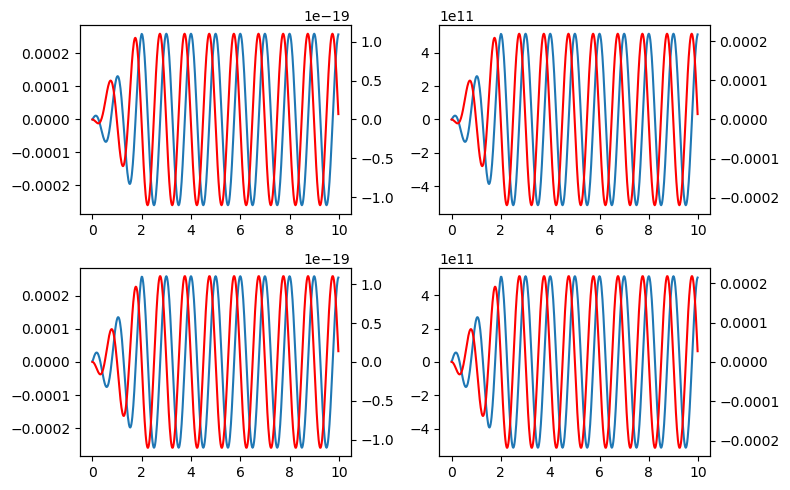

In [1]:
import numpy as np
from grid import UniformCartesianGrid
from  Field import polarizedElectricField, lambda2T, env_lin, polarizedPotentialVectorField
from pprint import pprint
import matplotlib.pyplot as plt
from IPython.display import HTML

def my_env(t:np.array, parameters):
    dt=t[1]-t[0]
    tmax=t[-1]+dt
    return np.sin(t/tmax*np.pi)

lambda0=800
T0=lambda2T(lambda0*1e-9)

# temporal grid
time=UniformCartesianGrid(1,[0,10*T0], 500)

# electricField
I0=3.51e16
Efield=polarizedElectricField(time,I0,800, env=env_lin, env_parameters={'start':0, 'end':1, 'ton':2*T0/time.x[-1], 'toff':2*T0/time.x[-1]*0}, 
                              chi_rad=np.pi/2, ellip=0)
#Afield=potentialVectorField(time,I0,800, phi_rad=-np.pi/2, env=env_lin, env_parameters={'start':0, 'end':1, 'ton':2*T0/time.x[-1], 'toff':2*T0/time.x[-1]*0})

#anim=Efield.showAnimation(interval=50, step=5)

#plt.close()

#HTML(anim.to_jshtml())

fig,ax=plt.subplots(2,2, figsize=(8,5))

ax_aux=ax[0,0].twinx()
ax[0,0].plot(Efield.t/Efield.T0, Efield.E[:,0])
ax_aux.plot(Efield.t/Efield.T0, Efield.A[:,0], c='r')

ax_aux=ax[0,1].twinx()
ax[0,1].plot(Efield.t/Efield.T0, Efield.E[:,1])
ax_aux.plot(Efield.t/Efield.T0, Efield.A[:,1], c='r')

Afield=polarizedPotentialVectorField(time,I0,800, env=env_lin, env_parameters={'start':0, 'end':1, 'ton':2*T0/time.x[-1], 'toff':2*T0/time.x[-1]*0}, phi_rad=-np.pi/2,
                              chi_rad=np.pi/2, ellip=0)

ax_aux=ax[1,0].twinx()
ax[1,0].plot(Afield.t/Afield.T0, Afield.E[:,0])
ax_aux.plot(Afield.t/Afield.T0, Afield.A[:,0], c='r')

ax_aux=ax[1,1].twinx()
ax[1,1].plot(Afield.t/Efield.T0, Afield.E[:,1])
ax_aux.plot(Afield.t/Afield.T0, Afield.A[:,1], c='r')

plt.tight_layout()



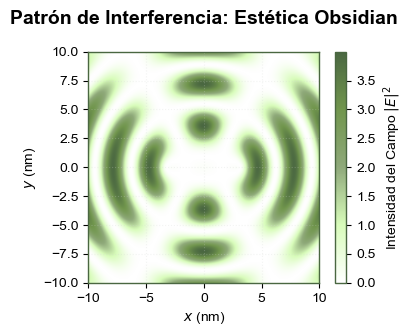

In [4]:
import numpy as np
from grid import UniformCartesianGrid
from  Field import electricField, lambda2T, env_sin2, env_lin, potentialVectorField
from pprint import pprint
import matplotlib.pyplot as plt
import obsidian_style

x = np.linspace(-10, 10, 500)
y = np.linspace(-10, 10, 500)
X, Y = np.meshgrid(x, y)

# Simulación de dos fuentes coherentes
r1 = np.sqrt((X - 3)**2 + Y**2)
r2 = np.sqrt((X + 3)**2 + Y**2)
Z = np.sin(r1) + np.sin(r2)
intensity = Z**2  # La intensidad es el cuadrado de la amplitud

# 3. Visualización con el estilo Obsidian
plt.style.use('obsidian') # Usamos tu .mplstyle
fig, ax = plt.subplots(figsize=(4, 3))

# Creamos el mapa de densidad
im = ax.imshow(intensity, extent=[-10, 10, -10, 10], 
               origin='lower', cmap='obsidian', interpolation='bilinear')

# Añadimos la barra de colores integrada en la estética
cbar = fig.colorbar(im, ax=ax, label='Intensidad del Campo $|E|^2$')
cbar.set_label('Intensidad del Campo $|E|^2$', color='k', weight='normal')

ax.set_title('Patrón de Interferencia: Estética Obsidian', pad=20)
ax.set_xlabel('$x$ (nm)')
ax.set_ylabel('$y$ (nm)')

plt.show()

In [2]:
import os
import matplotlib
style_dir = os.path.join(matplotlib.get_configdir(), 'stylelib')
os.makedirs(style_dir, exist_ok=True)
print(f"Copia el archivo aquí: {style_dir}")

Copia el archivo aquí: /Users/lplaja/.matplotlib/stylelib


In [2]:
plt.style.use('obsidian')